# 04_evaluation — モデルの評価とチューニング

学習したモデルの **性能を測り、改善する** ノートブックです。

## このノートブックで扱うこと

| # | テーマ |
|-|-|
| ① | **回帰の評価指標** (MAE / MSE / RMSE / R²) |
| ② | **分類の評価指標** (混同行列, Accuracy, Precision, Recall, F1) |
| ③ | **後処理によるチューニング** (クリッピング) |
| ④ | **アンサンブル学習** (バギング, ブースティング, スタッキング) |
| ⑤ | **XGBoost との比較** |


In [1]:
# ===== プロジェクトの src/ を import できるようにする共通の準備 =====
# notebooks/ から見て1つ上の階層がプロジェクトルート (= data_analysis_project)
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)


PROJECT_ROOT = /Users/kenta.hoji.ea/Desktop/pythonデータ分析/data_analysis_project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data_loader, features, modeling, evaluation

%matplotlib inline
sns.set_theme(style='whitegrid')


## データとモデルの読み込み

In [3]:
df = data_loader.load_processed('california_housing_fe')
X, y = features.split_features_target(df, target_col='Price')

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2,
)

linear = modeling.load_model('linear_regression')
rf     = modeling.load_model('random_forest')
print('models loaded.')


models loaded.


## ① 回帰の評価指標

回帰モデルがどれくらい正確に予測できているかを測る指標です。

### 平均絶対誤差 (MAE)

$$
\text{MAE} = \frac{1}{n}\sum_{i=1}^n |y_i - \hat{y}_i|
$$

- 意味: 予測値と真値の **絶対誤差** の平均
- 単位: 目的変数と同じ
- 外れ値の影響を受けにくい

### 平均二乗誤差 (MSE)

$$
\text{MSE} = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2
$$

- 意味: 予測値と真値の **二乗誤差** の平均
- 大きな誤差を **強く罰する**
- 単位は目的変数の 2 乗 (解釈しにくい)

### 平均二乗誤差の平方根 (RMSE)

$$
\text{RMSE} = \sqrt{\text{MSE}}
$$

- MSE の平方根 → **単位が目的変数と同じ** になる
- 実務でよく使われる
- やはり大きな誤差を強く罰する

### 決定係数 (R²)

$$
R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}
$$

- 意味: モデルがデータのバラつきを **どれくらい説明できるか**
- 1 に近いほど良い (1 = 完璧, 0 = 平均値を返すのと同じ, 負 = 平均値より悪い)


In [4]:
# 線形回帰の評価
y_pred_lin = linear.predict(X_test)
metrics_lin = evaluation.regression_metrics(y_test, y_pred_lin)
evaluation.print_metrics('LinearRegression (no clipping)', metrics_lin)

# ランダムフォレストの評価
y_pred_rf = rf.predict(X_test)
metrics_rf = evaluation.regression_metrics(y_test, y_pred_rf)
evaluation.print_metrics('RandomForest', metrics_rf)


=== LinearRegression (no clipping) ===
   MAE: 0.5107
   MSE: 0.4901
  RMSE: 0.7001
    R2: 0.6362
=== RandomForest ===
   MAE: 0.3649
   MSE: 0.2986
  RMSE: 0.5465
    R2: 0.7783


### MAE vs RMSE の使い分け

| 指標 | 特徴 | 使いどころ |
|-|-|-|
| **MAE** | 全ての誤差を等しく扱う | 外れ値が問題ない場面 |
| **MSE / RMSE** | 大きな誤差を強く罰する | 大きく外すと困る場面 (大きな誤差を避けたい) |

R² は 0〜1 の比率で比較しやすく、**異なる目的変数のモデルでも比較可能** な指標。


## ② 分類の評価指標 (参考)

今回のタスクは回帰ですが、分類タスクで使う代表指標も知っておきましょう。

### 混同行列 (Confusion Matrix)

|        | 予測: Positive | 予測: Negative |
|-|-|-|
| **実際: Positive** | TP (真陽性) | FN (偽陰性) |
| **実際: Negative** | FP (偽陽性) | TN (真陰性) |

### 主要指標

- **正解率 (Accuracy)** = $(TP + TN) / (TP + TN + FP + FN)$
  - 全体の中で正解したものの割合
  - **クラスが偏ったデータでは無意味になりがち** (例: 99% が陰性なら、全部陰性と予測すれば 99% 当たる)

- **適合率 (Precision)** = $TP / (TP + FP)$
  - 「Positive と予測したもの」のうち本当に Positive だった割合
  - **誤検知を減らしたい** ときに重要 (例: スパム判定で本物のメールをスパムと言いたくない)

- **再現率 (Recall)** = $TP / (TP + FN)$
  - 「本当の Positive」のうち見逃さず捕まえた割合
  - **見逃しを減らしたい** ときに重要 (例: 病気の見逃しを避けたい)

- **F1 スコア** = Precision と Recall の調和平均
  - Precision と Recall のバランスを取った指標


混同行列:
[[1658  379]
 [ 424 1667]]

Accuracy : 0.8055
Precision: 0.8148
Recall   : 0.7972
F1       : 0.8059


/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/pyth

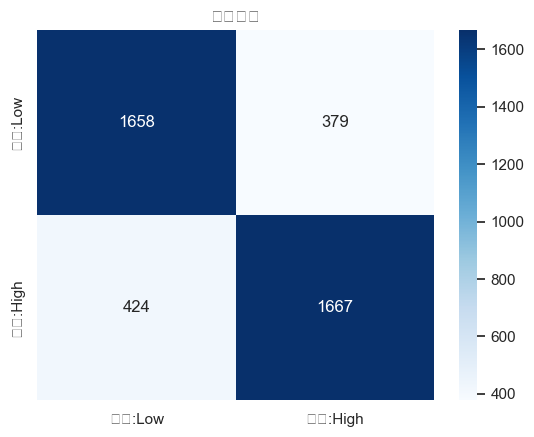

In [5]:
# サンプルとして二値分類のデモ
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

# Price が中央値より高いかどうかの二値分類問題に変換 (デモ)
median = df['Price'].median()
y_bin = (y > median).astype(int)

from sklearn.linear_model import LogisticRegression
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(X, y_bin, test_size=0.2, random_state=2)
clf = LogisticRegression(max_iter=1000).fit(Xb_tr, yb_tr)
yp = clf.predict(Xb_te)

cm = confusion_matrix(yb_te, yp)
print('混同行列:')
print(cm)
print()
print(f'Accuracy : {accuracy_score(yb_te, yp):.4f}')
print(f'Precision: {precision_score(yb_te, yp):.4f}')
print(f'Recall   : {recall_score(yb_te, yp):.4f}')
print(f'F1       : {f1_score(yb_te, yp):.4f}')

# 可視化
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['予測:Low', '予測:High'],
            yticklabels=['実際:Low', '実際:High'])
plt.title('混同行列')
plt.show()


## ③ 後処理によるチューニング (クリッピング)

EDA で `Price` が **5.00001 で上限処理** されていることに気づきました。
予測値もこの範囲を超えないように **クリッピング** すれば指標が改善するはずです。


In [6]:
# クリッピングなし
metrics_no_clip = evaluation.regression_metrics(y_test, y_pred_lin)

# クリッピング [0, 5.00001]
y_pred_clip = np.clip(y_pred_lin, 0.0, 5.00001)
metrics_clip = evaluation.regression_metrics(y_test, y_pred_clip)

print('線形回帰の指標比較:')
df_compare = pd.DataFrame({
    'no clip': metrics_no_clip,
    'clipped': metrics_clip,
}).T
print(df_compare.round(5))


線形回帰の指標比較:
             MAE      MSE     RMSE       R2
no clip  0.51065  0.49011  0.70008  0.63615
clipped  0.50100  0.47455  0.68888  0.64770


**観察**: わずかですが MAE / MSE / RMSE が改善し、R² も少し上昇します。
EDA で得た「気づき」がそのまま精度改善に効く好例です。

### 後処理が有効な主なケース

| ケース | 対応 |
|-|-|
| 値域がはっきり決まっている (例: 0〜100%) | min/max でクリッピング |
| 分類の確率閾値を調整したい | しきい値を 0.5 以外にする |
| 予測結果を四捨五入したい | `np.round` |
| 整数のはずなのに小数で出る | `np.round` or `int` キャスト |


## ④ アンサンブル学習

**複数のモデルを組み合わせて 1 つの強力なモデルを作る** 手法。
データ分析コンペ (Kaggle 等) では、ほぼ必ずアンサンブル学習が登場します。

### 主な 3 種類

#### 1. バギング (Bagging)

- 「**Bootstrap Aggregating**」の略
- 学習データから **重複ありの抽出** (ブートストラップ) を複数回行い、それぞれでモデルを学習
- 最終的に **平均 (回帰) / 多数決 (分類)** で予測
- 過学習を抑制し、安定した予測
- 代表例: **Random Forest**

#### 2. ブースティング (Boosting)

- 弱学習器を **順番に** 学習させ、前のモデルの誤りを次のモデルが修正
- 高い精度が出やすい
- 代表例: **AdaBoost, Gradient Boosting, XGBoost, LightGBM**

#### 3. スタッキング (Stacking)

- 異なる種類のモデル (ベースモデル) の予測結果を **入力にして**、別のメタモデルが最終予測
- 多様なモデルを統合して精度を引き上げる

### メリット・デメリット

| | メリット | デメリット |
|-|-|-|
| 精度 | 単一モデルより向上 | - |
| 過学習 | バギングは抑制 | スタッキングは過学習しやすい |
| 計算 | - | コストが大きい |
| 解釈性 | - | ブラックボックス化しがち |


## ⑤ XGBoost との比較

XGBoost は **勾配ブースティング決定木** の代表的な実装。
データ分析コンペで多用されるアルゴリズムです。
公式: <https://xgboost.readthedocs.io/>

特徴:
- 高精度 (とくに表形式データ)
- 欠損値を内部処理できる
- 学習が比較的高速 (並列化対応)
- 過学習を防ぐパラメータが豊富


In [7]:
try:
    xgb = modeling.train_xgboost(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    y_pred_xgb_clip = np.clip(y_pred_xgb, 0.0, 5.00001)

    metrics_xgb = evaluation.regression_metrics(y_test, y_pred_xgb_clip)

    # 3 モデルを比較
    summary = pd.DataFrame({
        'LinearRegression (clip)': evaluation.regression_metrics(y_test, np.clip(y_pred_lin, 0, 5.00001)),
        'RandomForest (clip)':     evaluation.regression_metrics(y_test, np.clip(y_pred_rf, 0, 5.00001)),
        'XGBoost (clip)':          metrics_xgb,
    }).T
    print('全モデルの比較 (クリッピング後):')
    print(summary.round(4))

    modeling.save_model(xgb, 'xgboost')
except ImportError as e:
    print('xgboost が未インストールのためスキップ:', e)
    summary = None


全モデルの比較 (クリッピング後):
                            MAE     MSE    RMSE      R2
LinearRegression (clip)  0.5010  0.4746  0.6889  0.6477
RandomForest (clip)      0.3649  0.2986  0.5465  0.7783
XGBoost (clip)           0.3085  0.2221  0.4713  0.8351


## ⑥ 残差プロットで質的な評価

数値指標だけでなく、**真値 vs 予測値** や **残差 (誤差)** を可視化すると、モデルの傾向が見えてきます。


/var/folders/f2/dyf3ym2n7kgb2_9yskmdtj0jr9qsrg/T/ipykernel_4588/450078066.py:20: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/f2/dyf3ym2n7kgb2_9yskmdtj0jr9qsrg/T/ipykernel_4588/450078066.py:20: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/f2/dyf3ym2n7kgb2_9yskmdtj0jr9qsrg/T/ipykernel_4588/450078066.py:20: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/f2/dyf3ym2n7kgb2_9yskmdtj0jr9qsrg/T/ipykernel_4588/450078066.py:20: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/f2/dyf3ym2n7kgb2_9yskmdtj0jr9qsrg/T/ipykernel_4588/450078066.py:20: UserWarning: Glyph 27531 (\N{CJK UNIFIED IDEOGRAPH-6B8B}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/f2/dyf3ym2n7kgb2_9yskmdtj0jr9qsrg/T/ipykernel_4

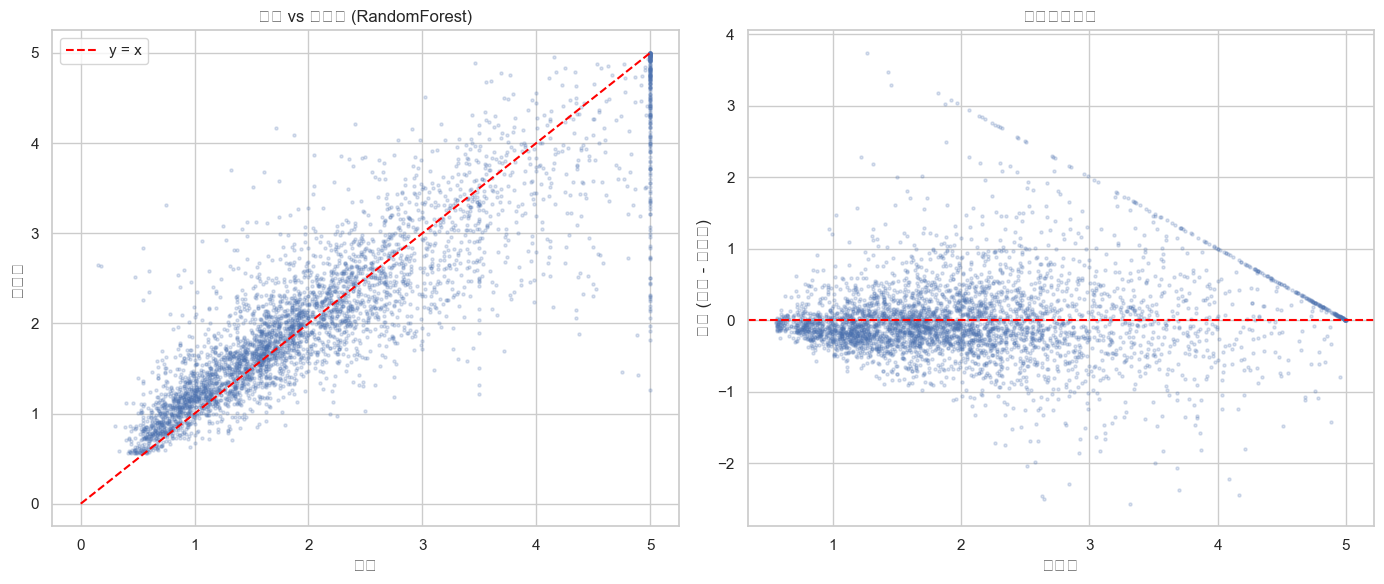

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 真値 vs 予測値 (理想は y = x の対角線)
y_pred_final = np.clip(rf.predict(X_test), 0, 5.00001)
axes[0].scatter(y_test, y_pred_final, alpha=0.2, s=5)
axes[0].plot([0, 5], [0, 5], color='red', linestyle='--', label='y = x')
axes[0].set_xlabel('真値')
axes[0].set_ylabel('予測値')
axes[0].set_title('真値 vs 予測値 (RandomForest)')
axes[0].legend()

# 残差プロット
residuals = y_test - y_pred_final
axes[1].scatter(y_pred_final, residuals, alpha=0.2, s=5)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('予測値')
axes[1].set_ylabel('残差 (真値 - 予測値)')
axes[1].set_title('残差プロット')

plt.tight_layout()
plt.show()


### 残差プロットから読み取れること

- 残差がランダムに散らばっている → モデルは適切
- 残差にパターンがある → モデルが捕らえきれていない構造あり
- 残差が一方に偏っている → モデルにバイアスあり
- 残差の分散が予測値で変わる (扇形) → 異分散性 (誤差の大きさが値域で違う)


## ⑦ チューニング戦略のまとめ

モデルの性能を上げるための代表的な手段:

| 手法 | 内容 | 効果 |
|-|-|-|
| **ハイパーパラメータチューニング** | 学習率, 木の深さ等を調整 (グリッドサーチ / Optuna) | 中〜大 |
| **特徴量エンジニアリング** | 新しい列を作る, 不要な列を消す | 大 (最も効きやすい) |
| **アンサンブル学習** | 複数モデルを組み合わせ | 中〜大 |
| **正則化** | L1 / L2 / Dropout | 過学習対策 |
| **データ追加** | データを増やす, データ拡張 | 大 (一般に最強の打ち手) |
| **後処理** | クリッピング, しきい値調整 | 小〜中 |
| **モデル変更** | より複雑なモデル, NN | 中 |

実務では「**特徴量エンジニアリング → アンサンブル → ハイパーパラメータチューニング**」の順で
取り組むことが多いです (一番効くのが特徴量エンジニアリング)。


## まとめ

- 回帰の評価指標は **MAE / MSE / RMSE / R²**。タスクに応じて使い分ける
- 分類は **混同行列 + Precision/Recall/F1** が基本
- **EDA の気づきを後処理に活かす** (クリッピングなど)
- 単一モデルから **アンサンブル学習** へ移行すると精度が上がる
- 数値指標だけでなく **残差プロット** で質的にも評価する

これでデータ分析の一連の流れが完成。  
コマンドラインから一括で実行したい場合は、プロジェクトルートの `main.py` を使う。
